In [1]:
from grid_world import GridWorldEnv
from dynamic_programming import value_iteration
from mdp import extract_mdp
import numpy as np
import matplotlib.pyplot as plt

# Create Grid World Environment

In [2]:
# Create new environment with (row, col) coordinates
env = GridWorldEnv(rows=5, cols=5, obstacles={(1, 1), (2, 2), (3, 1)})

***Markov Decision Process***
we want to get the states, actios and transition probabilites

In [3]:
states, actions, transition_probabilites = extract_mdp(env)

## Algorithms

## 1. Dynamic Programming using Value iteration

✅ Converged in 89 iterations, time = 0.012s


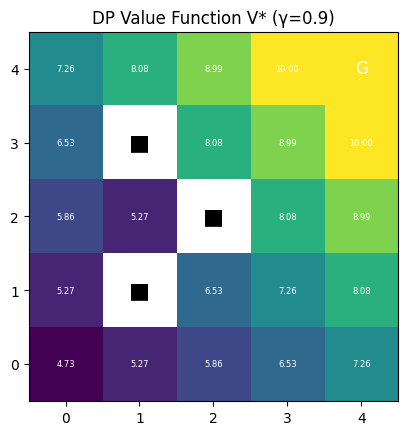

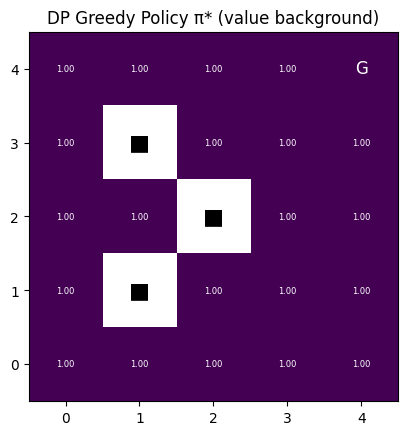

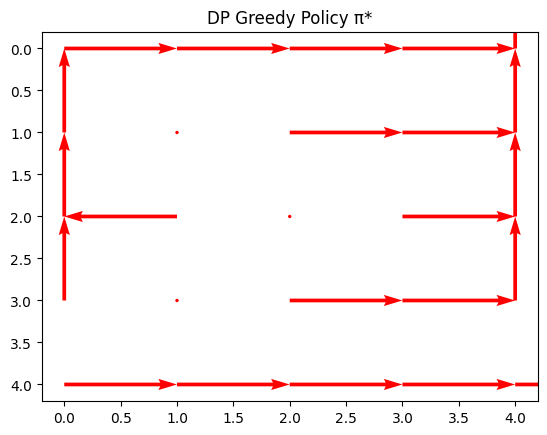

In [ ]:
# ┌─── Cell: Dynamic Programming (Value Iteration) ───────────────────────────────

import time
from utils import RLConfig, plot_value_function, plot_policy_arrows_from_q

# 2) Configure & run Value Iteration
config = RLConfig(gamma=0.9)  # use γ=0.9 as per assignment
start = time.time()
V_opt, pi_opt, iterations = value_iteration(
    states, actions, transition_probabilites, gamma=config.gamma, theta=1e-4
)
elapsed = time.time() - start
print(f"✅ Converged in {iterations} iterations, time = {elapsed:.3f}s")

# 3) Plot the optimal value function
plot_value_function(V_opt, env, title=f"DP Value Function V* (γ={config.gamma})")

# 4) Plot the greedy policy π* using our arrow‐plotting utility
#    We turn π into a “dummy Q” so we can reuse plot_policy_arrows_from_q:
Q_dummy = {(s, a): 1.0 if a == pi_opt[s] else 0.0 for s in states for a in actions}
plot_policy_arrows_from_q(Q_dummy, env, title="DP Greedy Policy π*")
# └───────────────────────────────────────────────────────────────────────────────

## 2. Monte Carlo Methods - using random policy

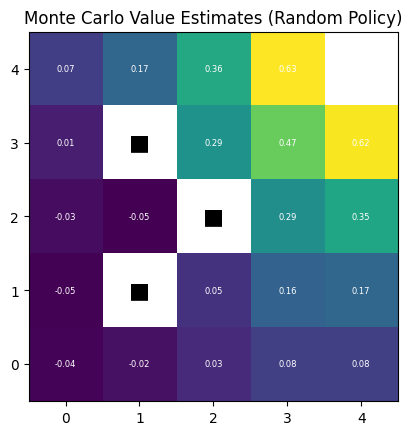

In [5]:
# ┌─── Cell: Monte Carlo Prediction (Random Policy) ───────────────────────────────
from monte_carlo import monte_carlo_prediction, random_policy_factory

# 2) Monte Carlo Prediction Config
config = RLConfig(gamma=0.9, episodes=1000, max_steps=100)

# 3) Use a random policy generator
random_policy = random_policy_factory(env.action_space)

# 4) Run Monte Carlo Prediction
V_mc = monte_carlo_prediction(
    env=env, policy=random_policy, num_episodes=config.episodes, gamma=config.gamma
)

# 5) Plot the learned value function
plot_value_function(V_mc, env, title="Monte Carlo Value Estimates (Random Policy)")
# └───────────────────────────────────────────────────────────────────────────────

## 3. Temporal Difference (TD) Learning

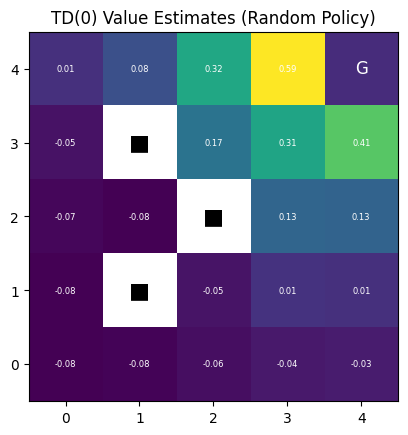

In [6]:
# ┌─── Cell: TD(0) Prediction (Random Policy) ─────────────────────────────────────
from algorithms import td0_prediction

# 2) TD(0) Config
config = RLConfig(gamma=0.9, alpha=0.1, episodes=1000, max_steps=100)

# 3) Define random policy
random_policy = random_policy_factory(env.action_space)

# 4) Run TD(0) Prediction
V_td = td0_prediction(
    env=env,
    policy=random_policy,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
)

# 5) Plot learned value function
plot_value_function(V_td, env, title="TD(0) Value Estimates (Random Policy)")
# └───────────────────────────────────────────────────────────────────────────────

## 4. Q-Learning

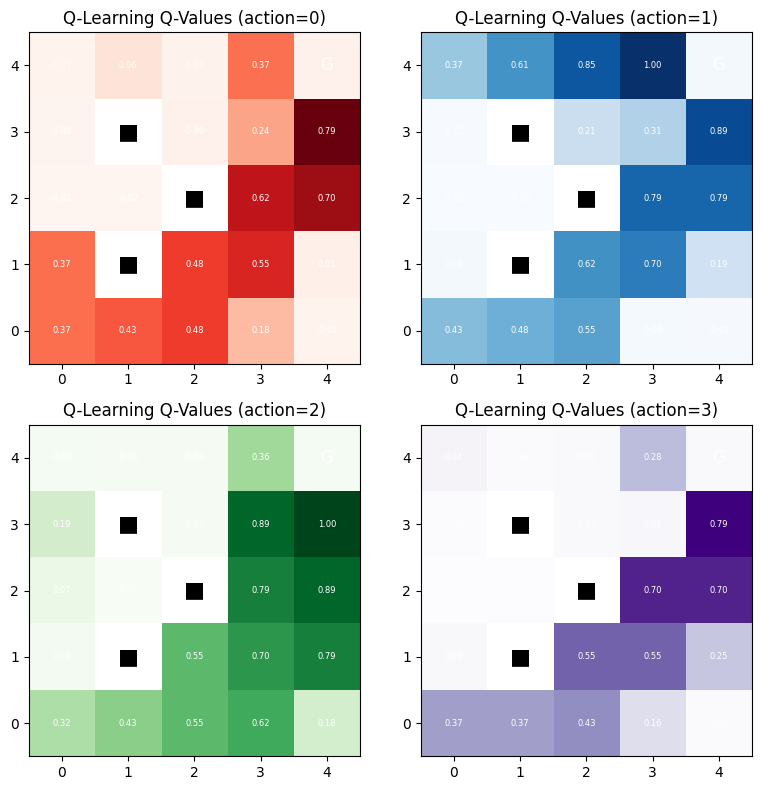

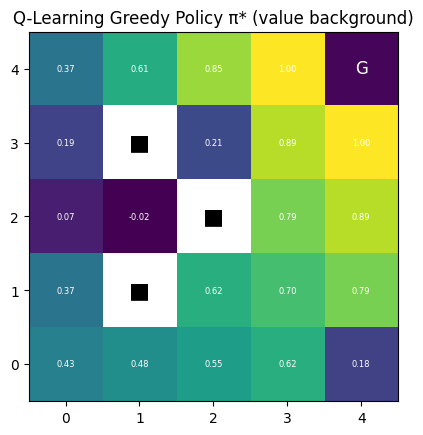

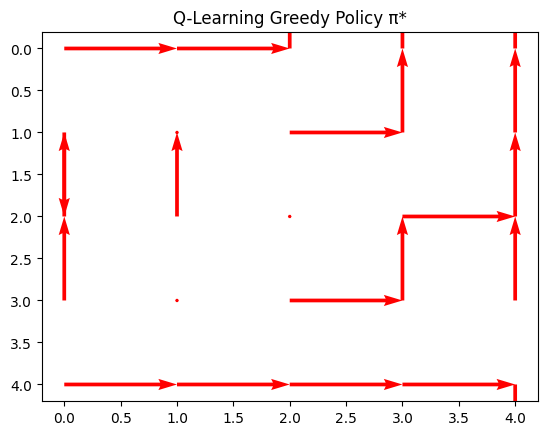

In [7]:
# ┌─── Cell: Q-Learning Control (ε-greedy) ────────────────────────────────────────
from algorithms import q_learning
from utils import plot_q_values

# 2) Q-Learning Config
config = RLConfig(gamma=0.9, alpha=0.1, epsilon=0.1, episodes=3000, max_steps=100)

# 3) Run Q-Learning
Q_q = q_learning(
    env=env,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
    epsilon=config.epsilon,
)

# 4) Plot Q-values per action
plot_q_values(Q_q, env, title="Q-Learning Q-Values")

# 5) Plot learned greedy policy derived from Q
plot_policy_arrows_from_q(Q_q, env, title="Q-Learning Greedy Policy π*")
# └───────────────────────────────────────────────────────────────────────────────

## 5. SARSA 

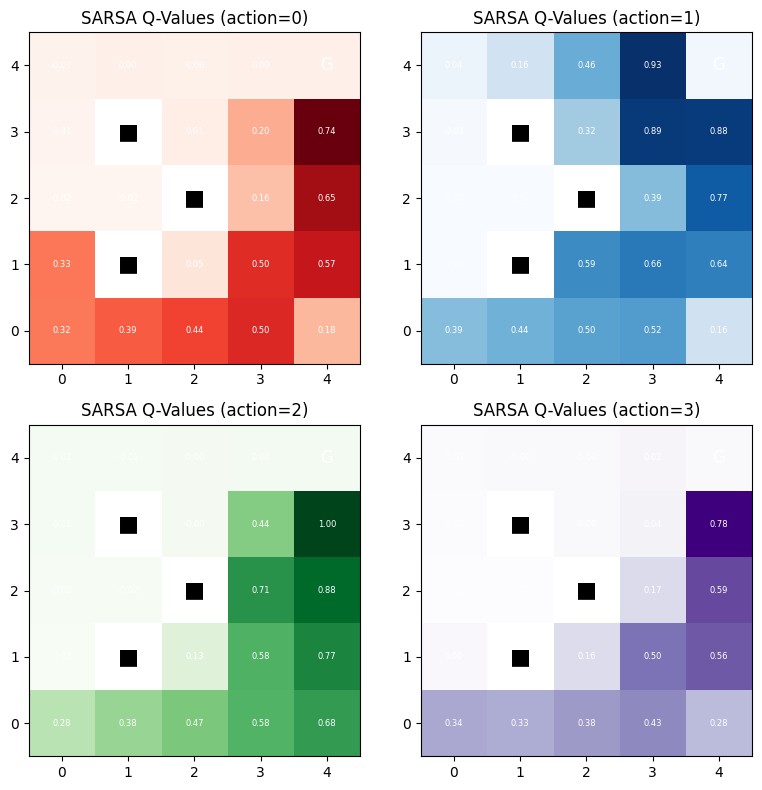

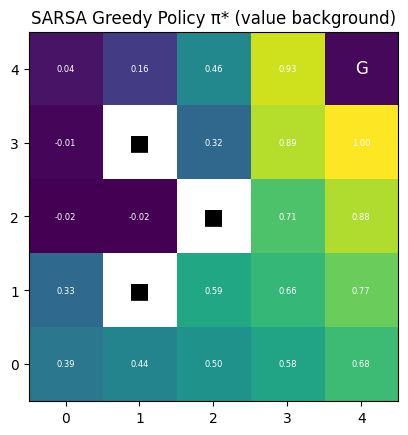

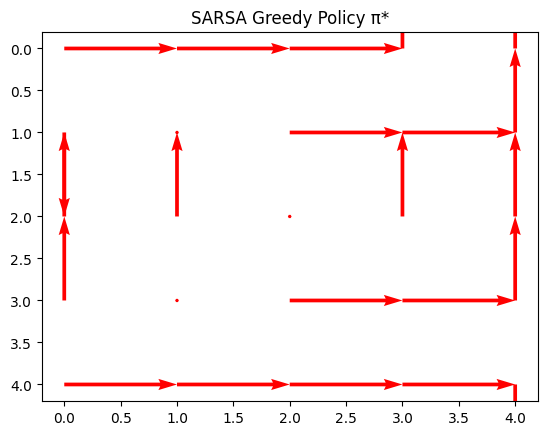

In [8]:
# ┌─── Cell: SARSA Control (ε-greedy) ─────────────────────────────────────────────
from algorithms import sarsa


# 2) SARSA Config
config = RLConfig(gamma=0.9, alpha=0.1, epsilon=0.1, episodes=3000, max_steps=100)

# 3) Run SARSA
Q_sarsa = sarsa(
    env=env,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
    epsilon=config.epsilon,
)

# 4) Plot Q-values for each action
plot_q_values(Q_sarsa, env, title="SARSA Q-Values")

# 5) Plot greedy policy learned from SARSA
plot_policy_arrows_from_q(Q_sarsa, env, title="SARSA Greedy Policy π*")
# └───────────────────────────────────────────────────────────────────────────────

## 6. TD(λ) with Eligibility Traces

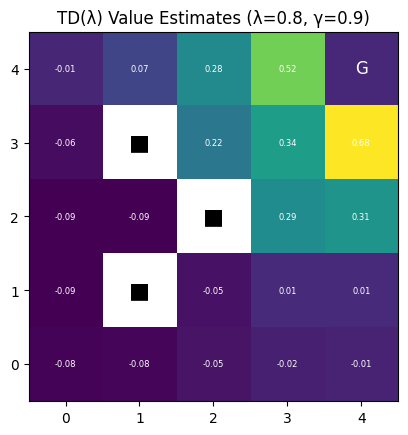

In [9]:
# ┌─── Cell: TD(λ) Prediction (Random Policy with Eligibility Traces) ─────────────

from algorithms import td_lambda

# 2) TD(λ) Config
config = RLConfig(gamma=0.9, alpha=0.1, episodes=1000, max_steps=100)
lambda_ = 0.8  # eligibility trace decay parameter

# 3) Define random policy
random_policy = random_policy_factory(env.action_space)

# 4) Run TD(λ) prediction
V_td_lambda = td_lambda(
    env=env,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
    lambda_=lambda_,
)

# 5) Plot predicted value function
plot_value_function(
    V_td_lambda, env, title=f"TD(λ) Value Estimates (λ={lambda_}, γ={config.gamma})"
)
# └───────────────────────────────────────────────────────────────────────────────